# LangGraph Lab: Inkwell Article Agent

A progressive learning notebook building agent orchestration concepts from LangChain Academy (Modules 1–6).

**Section 1** (complete) showcases a **ReAct agent** with tool-calling and multi-turn memory for managing Inkwell articles.

**Sections 2–6** are stubs previewing advanced concepts (state schemas, human-in-the-loop, parallelization, memory, deployment).


## Setup


In [6]:
import nest_asyncio

nest_asyncio.apply()

from dotenv import load_dotenv

load_dotenv()

# Section 1 uses mock data — no real GitHub token needed
print("✓ Environment loaded")

✓ Environment loaded


---

# Section 1: Module 1 — ReAct Agent with Tool-Calling & Memory

**Core concept:** ReAct loop + tool-calling + MemorySaver for multi-turn conversation.

**Scenario:** A conversational writing assistant. Ask it to "list my articles", "get content of article-slug", "create a draft", "append a section and save" — all in one thread. The agent decides which tool to call, reads the result, and replies naturally.

**Memory:** `MemorySaver` + `thread_id` carries full message history across turns — the agent remembers which article you discussed without repeating the slug.


### Mock Article Data

For safe experimentation, all tools operate against in-memory mock articles. No GitHub token, no real commits.


In [7]:
from dataclasses import dataclass
from datetime import datetime


@dataclass
class ArticleVersion:
    sha: str
    message: str
    committed_at: str


@dataclass
class ArticleMeta:
    slug: str
    title: str
    status: str  # "draft" or "published"
    tags: list[str]


@dataclass
class Article:
    slug: str
    content: str
    meta: ArticleMeta
    versions: list[ArticleVersion]


# Mock article store
MOCK_ARTICLES: dict[str, Article] = {
    "intro-langgraph": Article(
        slug="intro-langgraph",
        content="""# Introduction to LangGraph

LangGraph is a framework for building agentic systems with LLMs.

## What is a ReAct Agent?

ReAct stands for Reasoning + Acting. The agent loops:
1. Observe the current state
2. Reason about what to do next
3. Act by calling a tool
4. Return to step 1 with the tool result

This creates a multi-step problem-solving flow.
""",
        meta=ArticleMeta(
            slug="intro-langgraph",
            title="Introduction to LangGraph",
            status="draft",
            tags=["langgraph", "agents", "llm"],
        ),
        versions=[
            ArticleVersion(
                sha="abc123", message="Initial draft", committed_at="2025-04-10T10:00:00"
            ),
        ],
    ),
    "state-management": Article(
        slug="state-management",
        content="""# State Management in Graphs

Graph state is the core data structure that flows through your agent.

## State Design

Use TypedDict or Pydantic models to define your state schema.

Example:

```python
class AgentState(TypedDict):
    messages: list[AnyMessage]
    current_article: Article | None
```
""",
        meta=ArticleMeta(
            slug="state-management",
            title="State Management in Graphs",
            status="draft",
            tags=["langgraph", "state"],
        ),
        versions=[
            ArticleVersion(
                sha="def456",
                message="First pass",
                committed_at="2025-04-11T14:30:00",
            ),
        ],
    ),
    "tool-calling": Article(
        slug="tool-calling",
        content="""# Tool Calling in LangGraph

Agents call tools to interact with external systems. Tools are registered as LangChain `@tool` decorated functions.

## Example Tool

```python
@tool
def search_web(query: str) -> str:
    \"\"\"Search the web for information.\"\"\"
    # Implementation here
    return results
```
""",
        meta=ArticleMeta(
            slug="tool-calling",
            title="Tool Calling in LangGraph",
            status="draft",
            tags=["langgraph", "tools", "agents"],
        ),
        versions=[
            ArticleVersion(
                sha="ghi789",
                message="Initial outline",
                committed_at="2025-04-12T09:15:00",
            ),
        ],
    ),
}

print(f"✓ Loaded {len(MOCK_ARTICLES)} mock articles")
print("  Slugs:", ", ".join(MOCK_ARTICLES.keys()))

✓ Loaded 3 mock articles
  Slugs: intro-langgraph, state-management, tool-calling


### Tool Definitions

Four tools for the agent to manage Inkwell articles. Each tool reads/writes to `MOCK_ARTICLES`.

Note: Tool docstrings are the schema the LLM sees — make them precise.


In [ ]:
from langchain_core.tools import tool


@tool
def list_articles_tool() -> str:
    """List all articles in the user's Inkwell library.

    Returns a formatted table of slug, title, status, and tags.
    Use this to see what articles exist.
    """
    if not MOCK_ARTICLES:
        return "No articles found."

    lines = ["slug | title | status | tags"]
    for article in MOCK_ARTICLES.values():
        tags_str = ", ".join(article.meta.tags) if article.meta.tags else "(none)"
        lines.append(
            f"{article.meta.slug} | {article.meta.title} | {article.meta.status} | {tags_str}"
        )
    return "\n".join(lines)


@tool
def get_article_tool(slug: str) -> str:
    """Fetch the full content of an article by slug.

    Args:
        slug: The article slug (e.g., 'intro-langgraph').

    Returns the article's metadata (title, status, tags) and full markdown content.
    The content may be truncated if very long.
    """
    if slug not in MOCK_ARTICLES:
        return f"Article not found: {slug}"

    article = MOCK_ARTICLES[slug]
    content = article.content
    if len(content) > 2000:
        content = content[:2000] + f"\n\n[... truncated {len(article.content) - 2000} chars]"

    output = f"""
# {article.meta.title}
Slug: {article.meta.slug}
Status: {article.meta.status}
Tags: {", ".join(article.meta.tags) if article.meta.tags else "(none)"}

## Content

{content}

## Recent versions
"""
    for v in article.versions[-3:]:  # Last 3 versions
        output += f"\n- {v.message} ({v.committed_at})"

    return output


@tool
def create_article_tool(title: str, slug: str, tags: str, content: str) -> str:
    """Create a new draft article in Inkwell.

    Args:
        title: Article title.
        slug: URL-safe slug (must be unique, e.g., 'my-first-post').
        tags: Comma-separated tags (e.g., 'langgraph,agents').
        content: Full markdown content.

    Returns confirmation with the new slug.
    Status is always 'draft' on creation.
    """
    if slug in MOCK_ARTICLES:
        return f"Error: Article with slug '{slug}' already exists."

    tags_list = [t.strip() for t in tags.split(",") if t.strip()]
    new_article = Article(
        slug=slug,
        content=content,
        meta=ArticleMeta(slug=slug, title=title, status="draft", tags=tags_list),
        versions=[
            ArticleVersion(
                sha="new001",
                message="Initial draft",
                committed_at=datetime.now().isoformat(),
            )
        ],
    )
    MOCK_ARTICLES[slug] = new_article
    return f"✓ Created new article: {slug}"


@tool
def save_article_tool(slug: str, title: str, tags: str, content: str, message: str = "") -> str:
    """Save changes to an existing article.

    Args:
        slug: Article slug to update.
        title: Updated title.
        tags: Comma-separated tags.
        content: Updated markdown content.
        message: Commit message (auto-generated if empty).

    Returns confirmation with the commit message.
    """
    if slug not in MOCK_ARTICLES:
        return f"Error: Article not found: {slug}"

    article = MOCK_ARTICLES[slug]
    tags_list = [t.strip() for t in tags.split(",") if t.strip()]

    # Update article
    article.meta.title = title
    article.meta.tags = tags_list
    article.content = content

    # Add version
    if not message:
        message = f"update {slug}"
    article.versions.append(
        ArticleVersion(
            sha=f"sha_{len(article.versions)}",
            message=message,
            committed_at=datetime.now().isoformat(),
        )
    )

    return f"✓ Saved: {slug} — commit: '{message}'"


print("✓ All 4 tools defined")

✓ All 4 tools defined


### Graph Construction

Build a ReAct agent using the prebuilt `create_react_agent`. This handles the agent → tools → agent loop automatically.


✓ Agent created. Visualizing graph structure...


/var/folders/0n/jnq0jjbx7ggdh4q1j9_0mfzc0000gn/T/ipykernel_8838/2847743224.py:24: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


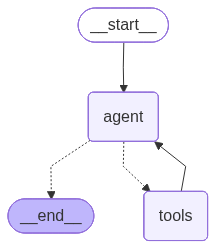

In [9]:
from IPython.display import Image, display
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent

# Initialize the LLM
llm = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0.1)

# Register tools
tools = [
    list_articles_tool,
    get_article_tool,
    create_article_tool,
    save_article_tool,
]

# Memory for multi-turn conversations
memory = MemorySaver()

# Create agent
# Note: create_react_agent automatically includes a sensible system prompt,
# so we don't need to provide one explicitly.
agent = create_react_agent(
    model=llm,
    tools=tools,
    checkpointer=memory,
)

print("✓ Agent created. Visualizing graph structure...")
display(Image(agent.get_graph().draw_mermaid_png()))

### Single-Turn Smoke Test

Verify the agent can list articles in one turn.


In [10]:
# Single-turn test
config = {"configurable": {"thread_id": "inkwell-lab-1"}}

result = await agent.ainvoke(
    {"messages": [HumanMessage(content="List all my articles")]}, config=config
)

print("Agent response:")
print(result["messages"][-1].content)

Agent response:
You have 3 articles in your Inkwell library:

| Slug | Title | Status | Tags |
|------|-------|--------|------|
| intro-langgraph | Introduction to LangGraph | draft | langgraph, agents, llm |
| state-management | State Management in Graphs | draft | langgraph, state |
| tool-calling | Tool Calling in LangGraph | draft | langgraph, tools, agents |

All three articles are currently in draft status. Would you like to view, edit, or create a new article?


### Multi-Turn Conversation Demo

Multi-turn conversation showing how MemorySaver carries context across turns.
The agent remembers which article you discussed without you repeating the slug.


In [ ]:
async def chat(user_input: str, thread_id: str = "inkwell-lab-1") -> str:
    """Send a message to the agent and get a response.

    Args:
        user_input: Your message to the agent.
        thread_id: Conversation thread ID (same thread = shared memory).

    Returns:
        The agent's response as a string.
    """
    config = {"configurable": {"thread_id": thread_id}}
    result = await agent.ainvoke({"messages": [HumanMessage(content=user_input)]}, config=config)
    return result["messages"][-1].content


print("Turn 1: List articles and pick the most complete one")
print("=" * 60)
response1 = await chat("List my articles and tell me which one looks most complete.")
print(response1)

print("\n" + "=" * 60)
print("Turn 2: Get the full content of the chosen article")
print("=" * 60)
response2 = await chat("Get the full content of that article. What's the current focus?")
print(response2)

print("\n" + "=" * 60)
print("Turn 3: Edit and save (agent remembers the article from Turn 1)")
print("=" * 60)
response3 = await chat(
    "Add a conclusion section that summarizes the key points and save it with commit message 'Add conclusion'."
)
print(response3)

print("\n✓ Multi-turn demo complete! The agent remembered which article was discussed.")

Turn 1: List articles and pick the most complete one
Based on reviewing all three articles, here's what I found:

| Slug | Title | Status | Content Length | Completeness |
|------|-------|--------|-----------------|--------------|
| intro-langgraph | Introduction to LangGraph | draft | ~250 words | ⭐⭐⭐ Most Complete |
| state-management | State Management in Graphs | draft | ~150 words | ⭐⭐ |
| tool-calling | Tool Calling in LangGraph | draft | ~100 words | ⭐ Least Complete |

**"Introduction to LangGraph" appears to be the most complete.** It has:
- A clear introduction explaining what LangGraph is
- A well-structured section on ReAct agents with numbered steps
- More detailed explanation of the concept
- Better organization overall

The other two articles are more skeletal—they have basic structure and code examples but lack the depth and explanation that the intro article provides. If you're looking to publish something soon, the intro article would be the best candidate after a fin

---

# Section 2: Module 2 — Richer State with Custom Schemas (TODO)

**Core concept:** Custom state schemas (TypedDict/Pydantic/Dataclass), reducers, message trimming.

**Inkwell scenario:** An editorial assistant that tracks structured state beyond raw messages:
- `messages`: list of conversation messages
- `current_article`: the article being edited (Article | None)
- `draft_history`: list of previous content snapshots (accumulated via `operator.add` reducer)
- `token_count`: running count of tokens processed

Message trimming keeps context bounded when editing long articles.

**APIs to use:**
- `TypedDict` or Pydantic `BaseModel` as the `StateGraph` schema
- `Annotated[list[str], operator.add]` reducer for accumulating draft history
- `trim_messages` from `langchain_core.messages` to limit context

**Implementation plan:**
1. Define `ArticleEditorState(TypedDict)` with the four fields above
2. Wire a `load_article` node that populates `current_article` from `MOCK_ARTICLES`
3. Wire a `trim_context` node that runs before each LLM call to limit message history
4. Add a `save_draft` node that records `content` to `draft_history`
5. Show how reducers automatically merge state updates


In [12]:
# TODO: Implement Section 2
# Step 1: Define ArticleEditorState with custom schema
# Step 2: Build StateGraph with load_article node
# Step 3: Add trim_messages before LLM calls
# Step 4: Show reducer behavior in action

print("\n⏸️  Section 2 stub — will be implemented as you progress through Module 2")
print("   See plan above for details on what will be built.")


⏸️  Section 2 stub — will be implemented as you progress through Module 2
   See plan above for details on what will be built.


---

# Section 3: Module 3 — Human-in-the-Loop for Destructive Actions (TODO)

**Core concept:** Static breakpoints, dynamic interrupts, edit-state-human-feedback, time-travel.

**Inkwell scenario:** Before the agent calls `save_article_tool`, pause execution and show the user:
- The proposed commit message
- A diff of changes (old vs new content)

The human can approve, edit the commit message, or reject entirely.
Time-travel feature: "roll back to before I told the agent to add that section."

**APIs to use:**
- `interrupt_before=["save_node"]` on `graph.compile(checkpointer=memory, interrupt_before=[...])`
- `graph.update_state(config, {"messages": [...]})` to inject a human edit mid-execution
- `graph.invoke(None, config)` to resume after approval
- `graph.get_state_history(config)` to browse past checkpoints
- `graph.invoke(None, config, checkpoint_id=...)` for time-travel resume

**Implementation plan:**
1. Add a `confirm_save` node between the agent reasoning and the `save_article_tool` call
2. The node raises `NodeInterrupt` with the proposed content and commit message
3. In a separate cell, show how to:
   - Call `graph.get_state()` to inspect what the agent decided
   - Call `graph.update_state()` to approve or modify the decision
   - Call `graph.invoke(None, config)` to resume
4. Show time-travel: `graph.get_state_history(config)` lists all checkpoints; resume at any one


In [13]:
# TODO: Implement Section 3
# Step 1: Add confirm_save node with interrupt_before
# Step 2: Show NodeInterrupt with diff display
# Step 3: Demonstrate graph.update_state() approval flow
# Step 4: Show time-travel with checkpoint history

print("\n⏸️  Section 3 stub — will be implemented as you progress through Module 3")
print("   See plan above for details on what will be built.")


⏸️  Section 3 stub — will be implemented as you progress through Module 3
   See plan above for details on what will be built.


---

# Section 4: Module 4 — Parallel Article Audit (Map-Reduce) (TODO)

**Core concept:** Parallelization via `Send`, sub-graphs, map-reduce pattern.

**Inkwell scenario:** "Audit all my articles" — a command that:
1. Lists all articles
2. Fans out in parallel to analyze each article
3. Fans back in to produce a consolidated editorial report

Each parallel audit checks:
- Missing tags? (should have at least 2)
- Very short content? (< 200 chars)
- No conclusion section? (no ## Conclusion or # Conclusion heading)

**APIs to use:**
- `Send` from `langgraph.types` to fan out per-article sub-graph instances
- A `article_auditor` sub-graph that takes `{slug}` and returns `{slug, issues: list[str]}`
- A `reduce_audit` node with `Annotated[list[dict], operator.add]` reducer on `audit_results`
- Conditional routing to `audit_router` that generates `Send(...)` per article

**Implementation plan:**
1. Define `audit_router(state)` node that returns `[Send("audit_article", {"slug": m.slug}) for m in metas]`
2. Define `audit_article(state)` node (or sub-graph) that analyzes the article and returns issues
3. Wire: START → audit_router → (parallel audit_article calls) → reduce_audit → END
4. Show the final report: "Article X has missing tags. Article Y is too short."


In [14]:
# TODO: Implement Section 4
# Step 1: Define audit_router that returns Send() per article
# Step 2: Define article_auditor node that checks for issues
# Step 3: Build StateGraph with parallel fan-out → fan-in
# Step 4: Run audit on mock articles and show consolidated report

print("\n⏸️  Section 4 stub — will be implemented as you progress through Module 4")
print("   See plan above for details on what will be built.")


⏸️  Section 4 stub — will be implemented as you progress through Module 4
   See plan above for details on what will be built.


---

# Section 5: Module 5 — Long-Term Writer Memory (TODO)

**Core concept:** LangGraph Memory Store for cross-thread, persistent memory. Profile vs. collection memory schemas.

**Inkwell scenario:** The agent remembers the user's writing preferences across sessions:
- Profile memory: single `WriterProfile` per user (preferred_tone: formal/casual, always_include_tags: list, liked_articles: list)
- Collection memory: per-article "notes to self" (research snippets, ideas discovered during editing)

Between sessions (different `thread_id`s), the agent loads this profile from the Store and tailors its suggestions:
- "I remember you prefer formal tone — I'll match that."
- "You always add tags [a, b, c] — should I add those to this article?"

**APIs to use:**
- `InMemoryStore` (or `AsyncPostgresStore` for production) passed to `create_react_agent(store=store)`
- `store.put(namespace, key, value)` / `store.get(namespace, key)` / `store.search(namespace, query)`
- Profile at `("users", user_id, "profile")` — single item, overwritten on update
- Notes at `("users", user_id, "article_notes", slug)` — multiple items, one per article
- `update_memory` node that runs after each agent turn and extracts memory updates from conversation

**Implementation plan:**
1. Define `WriterProfile` Pydantic model
2. Add `InMemoryStore()` to agent setup
3. Wire an `update_memory` node that parses agent messages for preference signals ("I prefer...", "Tag this with...")
4. Wire a `load_profile` node that runs at START to hydrate agent state with stored preferences
5. Demonstrate:
   - Turn 1 (new user): "I prefer casual tone and always tag my writing guides."
   - Turn 2 (different thread_id, same user): Agent loads profile and says "I remember you prefer casual tone."


In [15]:
# TODO: Implement Section 5
# Step 1: Define WriterProfile Pydantic model
# Step 2: Add InMemoryStore to agent
# Step 3: Wire load_profile and update_memory nodes
# Step 4: Show cross-session memory carry-over

print("\n⏸️  Section 5 stub — will be implemented as you progress through Module 5")
print("   See plan above for details on what will be built.")


⏸️  Section 5 stub — will be implemented as you progress through Module 5
   See plan above for details on what will be built.


---

# Section 6: Module 6 — LangGraph Platform Deployment (TODO)

**Core concept:** LangGraph Platform deployment, assistants versioning, double-texting prevention.

**Inkwell scenario:** The Section 1 agent deployed as a persistent service on LangGraph Platform.
The notebook connects via `LangGraphClient` and:
1. Creates two assistant configs over the same graph:
   - "Editorial Assistant" (verbose, detailed feedback)
   - "Terse Summarizer" (concise, quick edits)
2. Demonstrates double-texting strategies:
   - `enqueue`: new messages wait in line
   - `reject`: new messages are rejected while a run is in-flight
   - `rollback`: new messages abort the current run and start fresh

**APIs to use:**
- `langgraph_sdk.get_client(url=LANGGRAPH_URL)` — connect to deployed instance
- `client.assistants.create(graph_id="inkwell_agent", config={...})` — create variant configs
- `client.assistants.search()` — verify deployed graph is accessible
- `client.runs.create(thread_id, assistant_id, input)` — send work to agent
- `client.runs.stream(...)` — stream responses
- `multitask_strategy` parameter on run creation: `"enqueue"`, `"reject"`, or `"rollback"`

**Implementation plan:**
1. Add `LANGGRAPH_URL` and `LANGGRAPH_API_KEY` to `.env`
2. Connect via `get_client` and verify the deployed graph
3. Create two assistant configs with different state modifiers
4. Send the same article to both assistants and compare outputs
5. Demonstrate double-texting by sending two overlapping runs and showing each strategy


In [16]:
# TODO: Implement Section 6
# Step 1: Set up LANGGRAPH_URL in .env
# Step 2: Connect via LangGraphClient and verify deployment
# Step 3: Create two assistant configs (editorial vs terse)
# Step 4: Compare outputs from both assistants on the same input
# Step 5: Demonstrate multitask_strategy (enqueue, reject, rollback)

print("\n⏸️  Section 6 stub — will be implemented as you progress through Module 6")
print("   See plan above for details on what will be built.")


⏸️  Section 6 stub — will be implemented as you progress through Module 6
   See plan above for details on what will be built.
